<a href="https://colab.research.google.com/github/yuzonfire907/data-science-2026/blob/main/Pertemuan%207_Yustinus%20Budi%20Kristiawan_240401010299.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pertemuan 7 - Prediksi Gaji dengan Regresi Linear**

# **Nama : Yustinus Budi Kristiawan**
# **NIM : 240401010299**
# **Kelas : IF401**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # 0=SMA, 1=D3, 2=S1
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print("Shape:", df.shape)
display(df.head())

print("\nStatistik deskriptif:")
display(df.describe().round(2))

Shape: (300, 4)


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265



Statistik deskriptif:


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22


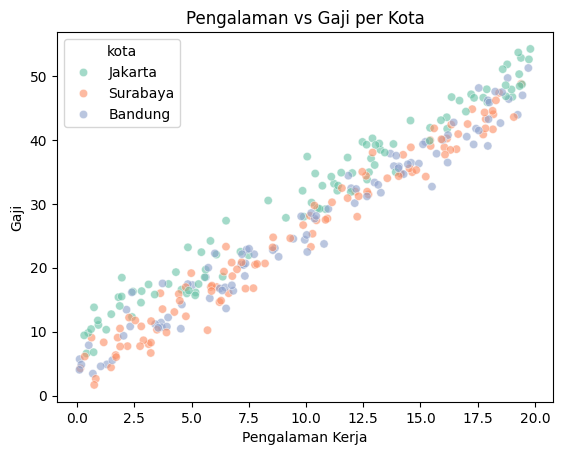

In [3]:
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman Kerja')
plt.ylabel('Gaji')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom kota
df_encoded = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding:")
print(df_encoded.columns.tolist())

# Pisahkan fitur dan target
X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

# StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris
Test : 60 baris


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f"β₀ (intercept): {model.intercept_:.3f}")

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

display(coef_df)

β₀ (intercept): 27.514


,Fitur,Koefisien
0,pengalaman,13.042
2,kota_Jakarta,1.837
1,edu,1.188
3,kota_Surabaya,-0.292


## Interpretasi Koefisien

Berdasarkan hasil koefisien, fitur dengan pengaruh paling besar terhadap gaji adalah pengalaman kerja. Semakin lama pengalaman kerja seseorang, maka gaji yang diprediksi cenderung semakin tinggi.

Fitur pendidikan juga berpengaruh positif terhadap gaji, artinya semakin tinggi tingkat pendidikan, gaji cenderung meningkat. Selain itu, kota tempat bekerja juga ikut memengaruhi gaji, terutama jika kota tersebut memiliki nilai koefisien positif.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Metrik Evaluasi ===")
print(f"MAE  = {mae:.3f} juta rupiah")
print(f"RMSE = {rmse:.3f} juta rupiah")
print(f"R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)")
print(f"Selisih RMSE-MAE = {rmse-mae:.3f}")

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


## Interpretasi Evaluasi Model

Nilai MAE menunjukkan rata-rata kesalahan prediksi model dalam satuan juta rupiah. Jika MAE kecil, berarti prediksi model cukup dekat dengan nilai gaji sebenarnya.

Nilai RMSE juga menunjukkan kesalahan prediksi, tetapi lebih sensitif terhadap kesalahan yang besar. Jika selisih RMSE dan MAE tidak terlalu jauh, maka tidak ada indikasi outlier yang terlalu besar pada hasil prediksi.

Nilai R² menunjukkan seberapa besar variasi gaji yang dapat dijelaskan oleh model. Jika nilai R² mendekati 1, maka model dapat menjelaskan data dengan sangat baik.

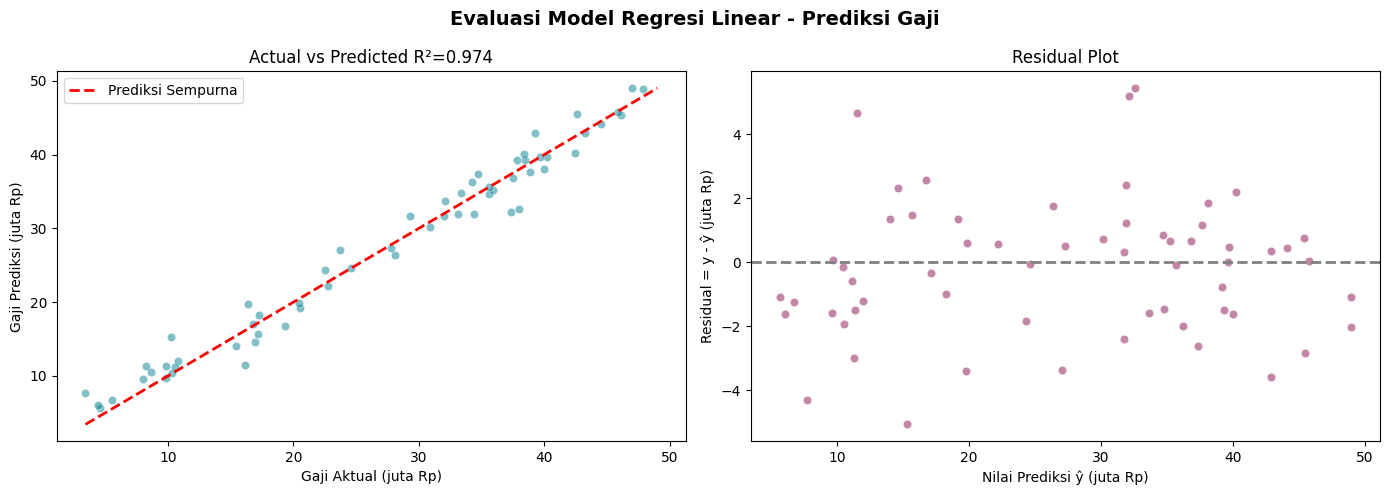

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y - ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle(
    'Evaluasi Model Regresi Linear - Prediksi Gaji',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretasi Visualisasi

Pada plot Actual vs Predicted, titik-titik yang mendekati garis merah menunjukkan bahwa hasil prediksi model cukup dekat dengan nilai gaji sebenarnya. Semakin dekat titik ke garis merah, semakin baik hasil prediksinya.

Pada Residual Plot, titik-titik terlihat menyebar di sekitar garis nol. Hal ini menunjukkan bahwa kesalahan prediksi cukup acak dan model Regresi Linear masih cocok digunakan untuk dataset ini.

Secara umum, model sudah dapat memprediksi gaji dengan cukup baik karena pola data yang digunakan memang memiliki hubungan linear antara pengalaman kerja, pendidikan, kota, dan gaji.

## Interpretasi Visualisasi

Pada plot Actual vs Predicted, titik-titik yang mendekati garis merah menunjukkan bahwa hasil prediksi model cukup dekat dengan nilai gaji sebenarnya. Semakin dekat titik ke garis merah, semakin baik hasil prediksinya.

Pada Residual Plot, titik-titik terlihat menyebar di sekitar garis nol. Hal ini menunjukkan bahwa kesalahan prediksi cukup acak dan model Regresi Linear masih cocok digunakan untuk dataset ini.

Secara umum, model sudah dapat memprediksi gaji dengan cukup baik karena pola data yang digunakan memang memiliki hubungan linear antara pengalaman kerja, pendidikan, kota, dan gaji.